# Data Validation: Sentinel-2 Irrigation Patches

Checks that image and label values are in expected ranges before training.

**What this covers:**
- Per-band value ranges (min, max, mean, std)
- NaN / Inf detection
- Label class distribution and valid class check
- Sample visualizations (RGB composite + label)
- Per-season comparison for temporal band group

In [1]:
import sys
sys.path.insert(0, "..")
sys.path.insert(0, "../src")

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

In [2]:
# ── Configuration ──────────────────────────────────────────
# Update these paths to match your setup
DATA_ROOT = Path("/scratch/gza5dr/IrrigationType_experiments/Colorado/Data/Claude_Code/irrigation_dataset")
STATES = ["Utah", "Colorado_Div5"]
SEASONS = ["s3", "s4", "s5"]
NUM_BANDS = 14
PATCH_SIZE = 224
VALID_LABELS = {0, 1, 2, 3, 255}  # 0=bg, 1=flood, 2=sprinkler, 3=drip, 255=ignore
LABEL_NAMES = {0: "background", 1: "flood", 2: "sprinkler", 3: "drip", 255: "ignore"}

# Sentinel-2 band names (14 bands as stored in the GeoTIFFs)
BAND_NAMES = [
    "B02", "B03", "B04", "B05", "B06", "B07", "B08",
    "B8A", "B11", "B12", "NDVI", "NDWI", "EVI", "SAVI"
]

# How many tiles to sample (set to None for all tiles)
MAX_TILES = 50

## 1. Discover tiles

In [3]:
tile_info = {}  # state -> list of tile names

for state in STATES:
    state_dir = DATA_ROOT / state
    label_dir = state_dir / "labels"
    if not label_dir.exists():
        print(f"WARNING: {label_dir} does not exist, skipping {state}")
        continue
    tiles = sorted([f.stem.replace("_label", "") for f in label_dir.glob("tile_*_label.tif")])
    if MAX_TILES:
        rng = np.random.RandomState(42)
        tiles = list(rng.choice(tiles, size=min(MAX_TILES, len(tiles)), replace=False))
    tile_info[state] = tiles
    print(f"{state}: {len(tiles)} tiles sampled")

Utah: 50 tiles sampled
Colorado_Div5: 50 tiles sampled


## 2. Image value ranges (per-band, per-season)

In [4]:
band_stats = {}  # (state, season, band_idx) -> {min, max, mean, std, nan_count, inf_count}

for state, tiles in tile_info.items():
    state_dir = DATA_ROOT / state / "images"
    for season in SEASONS:
        all_band_vals = [[] for _ in range(NUM_BANDS)]
        nan_counts = np.zeros(NUM_BANDS)
        inf_counts = np.zeros(NUM_BANDS)

        for tile_name in tiles:
            fpath = state_dir / f"{tile_name}_{season}.tif"
            if not fpath.exists():
                print(f"  MISSING: {fpath}")
                continue
            with rasterio.open(fpath) as src:
                data = src.read().astype(np.float32)  # (14, 224, 224)

            assert data.shape == (NUM_BANDS, PATCH_SIZE, PATCH_SIZE), \
                f"Unexpected shape {data.shape} for {fpath}"

            for b in range(NUM_BANDS):
                band = data[b]
                nan_counts[b] += np.isnan(band).sum()
                inf_counts[b] += np.isinf(band).sum()
                valid = band[np.isfinite(band)]
                if len(valid) > 0:
                    all_band_vals[b].append(valid)

        for b in range(NUM_BANDS):
            if all_band_vals[b]:
                concat = np.concatenate(all_band_vals[b])
                band_stats[(state, season, b)] = {
                    "min": concat.min(),
                    "max": concat.max(),
                    "mean": concat.mean(),
                    "std": concat.std(),
                    "nan_count": int(nan_counts[b]),
                    "inf_count": int(inf_counts[b]),
                }

print("Done collecting band statistics.")

Done collecting band statistics.


In [5]:
# Print summary table
print(f"{'State':<10} {'Season':<8} {'Band':<6} {'Name':<6} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'NaN':>8} {'Inf':>8}")
print("-" * 96)

issues = []
for (state, season, b), s in sorted(band_stats.items()):
    name = BAND_NAMES[b] if b < len(BAND_NAMES) else f"B{b}"
    print(f"{state:<10} {season:<8} {b:<6} {name:<6} {s['min']:>10.2f} {s['max']:>10.2f} {s['mean']:>10.2f} {s['std']:>10.2f} {s['nan_count']:>8} {s['inf_count']:>8}")

    if s["nan_count"] > 0:
        issues.append(f"NaN values in {state}/{season}/band {b} ({name}): {s['nan_count']}")
    if s["inf_count"] > 0:
        issues.append(f"Inf values in {state}/{season}/band {b} ({name}): {s['inf_count']}")
    # Reflectance bands (0-9) are typically 0-10000 for Sentinel-2 L2A
    if b < 10 and s["max"] > 20000:
        issues.append(f"Unusually high reflectance in {state}/{season}/band {b} ({name}): max={s['max']:.0f}")
    if b < 10 and s["min"] < -1000:
        issues.append(f"Negative reflectance in {state}/{season}/band {b} ({name}): min={s['min']:.0f}")
    # Index bands (10-13: NDVI, NDWI, EVI, SAVI) are typically -1 to 1
    if b >= 10 and (s["min"] < -2 or s["max"] > 2):
        issues.append(f"Index out of [-2, 2] range in {state}/{season}/band {b} ({name}): [{s['min']:.2f}, {s['max']:.2f}]")

print("\n" + "=" * 50)
if issues:
    print(f"⚠ Found {len(issues)} potential issues:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("All band values look reasonable.")

State      Season   Band   Name          Min        Max       Mean        Std      NaN      Inf
------------------------------------------------------------------------------------------------
Colorado_Div5 s3       0      B02          0.00       1.14       0.07       0.04        0        0
Colorado_Div5 s3       1      B03          0.00       1.08       0.10       0.05        0        0
Colorado_Div5 s3       2      B04          0.00       1.03       0.11       0.06        0        0
Colorado_Div5 s3       3      B05          0.00       0.93       0.28       0.07        0        0
Colorado_Div5 s3       4      B06          0.00       0.79       0.29       0.07        0        0
Colorado_Div5 s3       5      B07          0.00       0.94       0.28       0.07        0        0
Colorado_Div5 s3       6      B08          0.00       1.07       0.20       0.08        0        0
Colorado_Div5 s3       7      B8A          0.00       0.92       0.25       0.07        0        0
Colorado_Div5 s

## 3. Label distribution and validity

In [6]:
label_issues = []

for state, tiles in tile_info.items():
    label_dir = DATA_ROOT / state / "labels"
    class_counts = Counter()
    invalid_values = set()

    for tile_name in tiles:
        fpath = label_dir / f"{tile_name}_label.tif"
        with rasterio.open(fpath) as src:
            label = src.read(1)  # (224, 224)

        assert label.shape == (PATCH_SIZE, PATCH_SIZE), \
            f"Unexpected label shape {label.shape} for {fpath}"

        unique = set(np.unique(label))
        invalid = unique - VALID_LABELS
        if invalid:
            invalid_values.update(invalid)
            label_issues.append(f"Invalid label values in {state}/{tile_name}: {invalid}")

        for v in unique:
            class_counts[int(v)] += int((label == v).sum())

    print(f"\n{state} label distribution ({len(tiles)} tiles):")
    total = sum(class_counts.values())
    for cls in sorted(class_counts.keys()):
        name = LABEL_NAMES.get(cls, f"unknown_{cls}")
        count = class_counts[cls]
        pct = 100 * count / total
        print(f"  {cls} ({name:>12}): {count:>12,} pixels  ({pct:>5.1f}%)")

if label_issues:
    print(f"\n⚠ Found {len(label_issues)} label issues:")
    for issue in label_issues:
        print(f"  - {issue}")
else:
    print("\nAll label values are valid.")


Utah label distribution (50 tiles):
  0 (  background):    1,929,655 pixels  ( 76.9%)
  1 (       flood):      241,779 pixels  (  9.6%)
  2 (   sprinkler):      337,366 pixels  ( 13.4%)

Colorado_Div5 label distribution (50 tiles):
  0 (  background):    2,066,325 pixels  ( 82.4%)
  1 (       flood):      400,035 pixels  ( 15.9%)
  2 (   sprinkler):       42,440 pixels  (  1.7%)

All label values are valid.


## 4. Band value distributions (histograms)

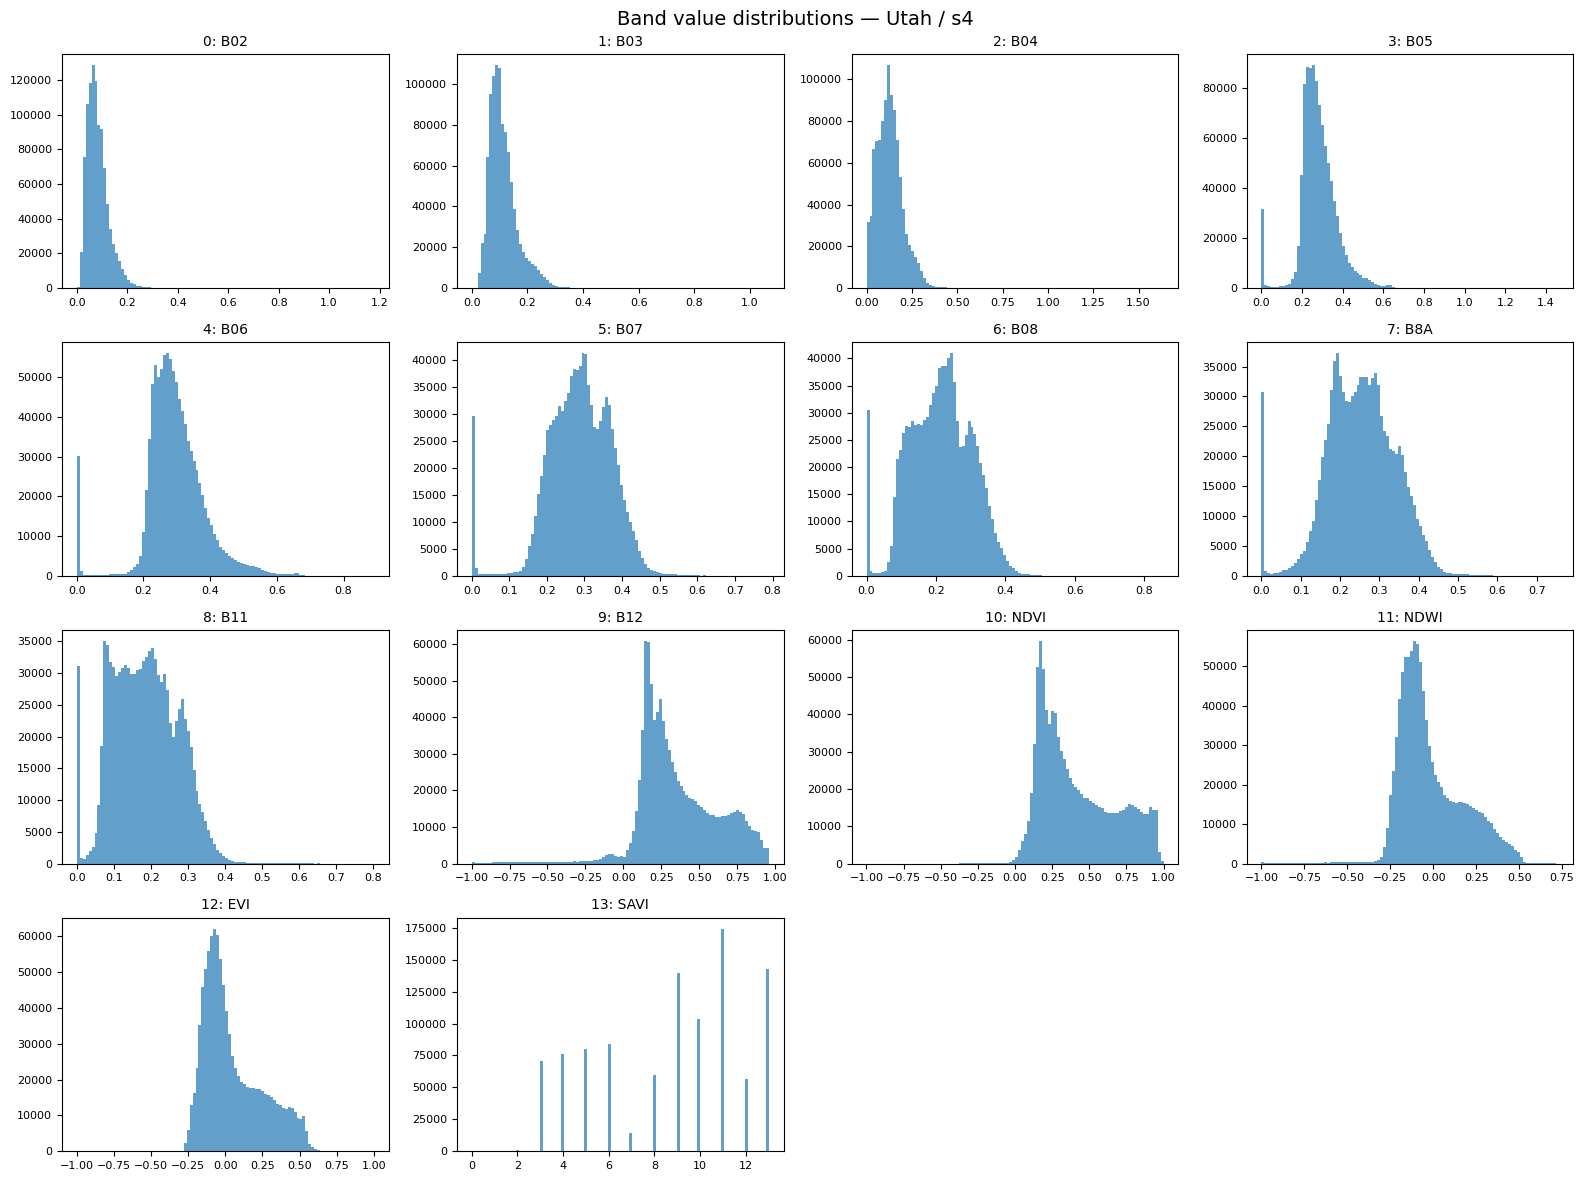

In [7]:
# Plot histograms for each band across one season (s4 = peak summer)
state = STATES[0]
season = "s4"
state_dir = DATA_ROOT / state / "images"

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle(f"Band value distributions — {state} / {season}", fontsize=14)

for b in range(NUM_BANDS):
    ax = axes[b // 4, b % 4]
    vals = []
    for tile_name in tile_info.get(state, [])[:20]:  # sample 20 tiles
        fpath = state_dir / f"{tile_name}_{season}.tif"
        if not fpath.exists():
            continue
        with rasterio.open(fpath) as src:
            data = src.read(b + 1).astype(np.float32).ravel()
        vals.append(data[np.isfinite(data)])
    if vals:
        concat = np.concatenate(vals)
        ax.hist(concat, bins=100, alpha=0.7, edgecolor="none")
    name = BAND_NAMES[b] if b < len(BAND_NAMES) else f"B{b}"
    ax.set_title(f"{b}: {name}", fontsize=10)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for b in range(NUM_BANDS, 16):
    axes[b // 4, b % 4].axis("off")

plt.tight_layout()
plt.show()

## 5. Sample visualization (RGB + label)

/tmp/ipykernel_603603/970359723.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_label = plt.cm.get_cmap("tab10", 5)
/tmp/ipykernel_603603/970359723.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


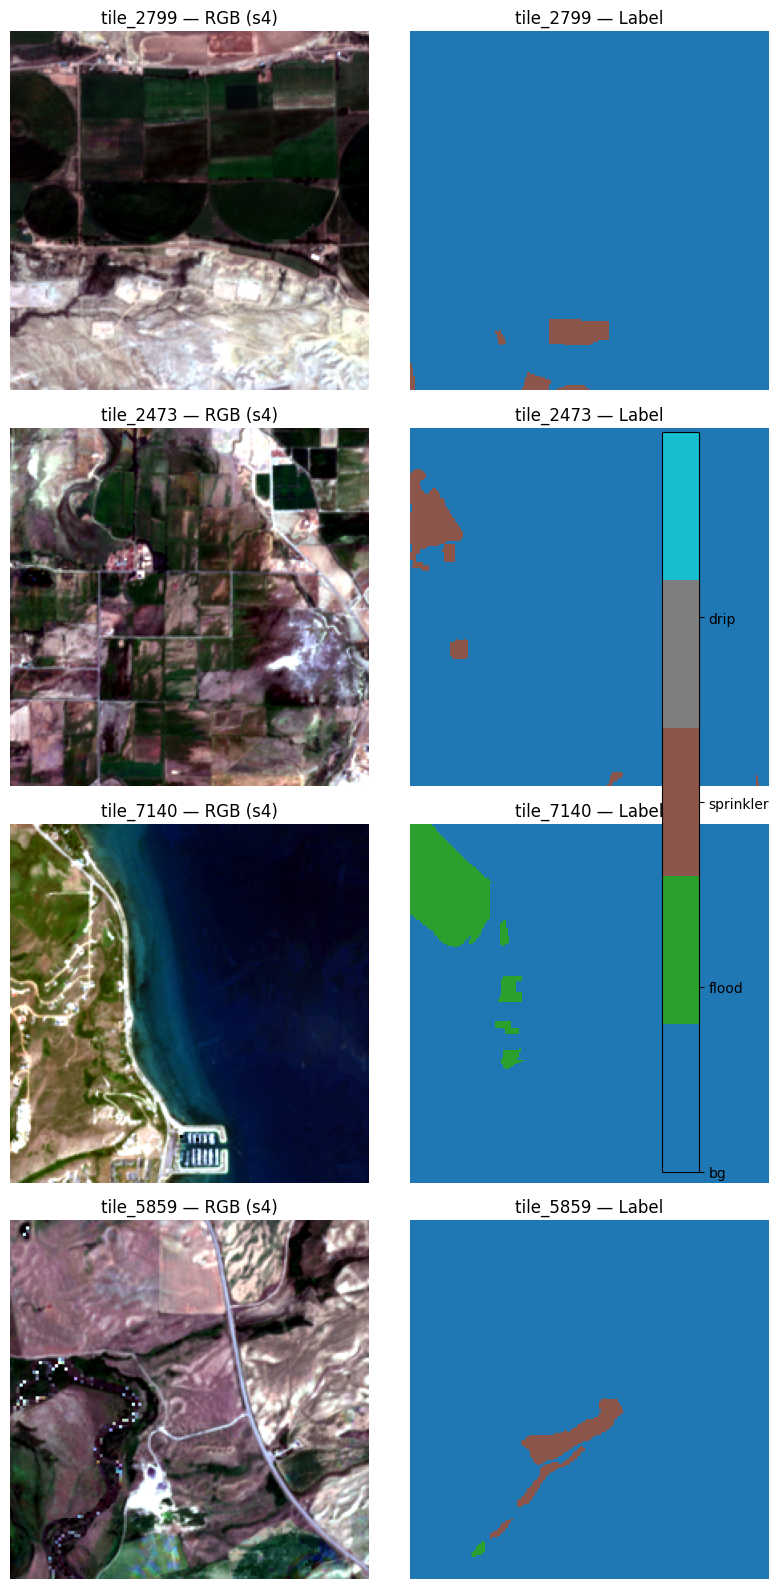

In [8]:
# Show a few sample tiles: RGB composite (bands 0,1,2 = B02,B03,B04) + label mask
state = STATES[0]
tiles_to_show = tile_info.get(state, [])[:4]

fig, axes = plt.subplots(len(tiles_to_show), 2, figsize=(8, 4 * len(tiles_to_show)))
if len(tiles_to_show) == 1:
    axes = axes[np.newaxis, :]

cmap_label = plt.cm.get_cmap("tab10", 5)

for i, tile_name in enumerate(tiles_to_show):
    # Load RGB from s4
    img_path = DATA_ROOT / state / "images" / f"{tile_name}_s4.tif"
    with rasterio.open(img_path) as src:
        data = src.read().astype(np.float32)
    rgb = data[[2, 1, 0]]  # B04, B03, B02 → R, G, B
    # Simple percentile stretch for visualization
    for c in range(3):
        lo, hi = np.percentile(rgb[c], [2, 98])
        rgb[c] = np.clip((rgb[c] - lo) / (hi - lo + 1e-6), 0, 1)
    rgb = np.transpose(rgb, (1, 2, 0))

    # Load label
    lbl_path = DATA_ROOT / state / "labels" / f"{tile_name}_label.tif"
    with rasterio.open(lbl_path) as src:
        label = src.read(1)

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"{tile_name} — RGB (s4)")
    axes[i, 0].axis("off")

    im = axes[i, 1].imshow(label, cmap=cmap_label, vmin=0, vmax=4, interpolation="nearest")
    axes[i, 1].set_title(f"{tile_name} — Label")
    axes[i, 1].axis("off")

# Add colorbar legend
cbar = fig.colorbar(im, ax=axes[:, 1], ticks=[0, 1, 2, 3], shrink=0.6)
cbar.ax.set_yticklabels(["bg", "flood", "sprinkler", "drip"])

plt.tight_layout()
plt.show()

## 6. Cross-season consistency check

Verify that band statistics are consistent across s3, s4, s5 — large jumps may indicate data issues.

In [9]:
for state in STATES:
    print(f"\n{'='*60}")
    print(f"{state} — Cross-season mean comparison")
    print(f"{'Band':<8}", end="")
    for s in SEASONS:
        print(f"  {s:>10}", end="")
    print(f"  {'Max Δ':>10}")
    print("-" * 52)

    for b in range(NUM_BANDS):
        means = []
        name = BAND_NAMES[b] if b < len(BAND_NAMES) else f"B{b}"
        print(f"{name:<8}", end="")
        for s in SEASONS:
            key = (state, s, b)
            if key in band_stats:
                m = band_stats[key]["mean"]
                means.append(m)
                print(f"  {m:>10.2f}", end="")
            else:
                print(f"  {'N/A':>10}", end="")
        if len(means) > 1:
            delta = max(means) - min(means)
            print(f"  {delta:>10.2f}")
        else:
            print()


Utah — Cross-season mean comparison
Band              s3          s4          s5       Max Δ
----------------------------------------------------
B02             0.08        0.08        0.08        0.01
B03             0.11        0.11        0.11        0.01
B04             0.12        0.13        0.12        0.00
B05             0.30        0.29        0.27        0.03
B06             0.31        0.31        0.29        0.03
B07             0.27        0.28        0.28        0.01
B08             0.20        0.21        0.20        0.00
B8A             0.24        0.24        0.24        0.00
B11             0.17        0.17        0.17        0.00
B12             0.42        0.39        0.37        0.05
NDVI            0.49        0.46        0.43        0.07
NDWI            0.05        0.01       -0.02        0.07
EVI             0.12        0.08        0.04        0.08
SAVI            7.80        8.21        6.88        1.34

Colorado_Div5 — Cross-season mean comparison
Band     

## 7. Dataset loading sanity check

Load a few samples through the actual `IrrigationDataset` to confirm the pipeline works end-to-end.

In [10]:
from irrigation.data.bands import get_band_config
from irrigation.data.dataset import IrrigationDataset

for band_group in ["temporal", "spectral_s4", "rgb_s4"]:
    bc = get_band_config(band_group)
    state_path = DATA_ROOT / STATES[0]
    tile_ids = [int(t.split("_")[1]) for t in tile_info.get(STATES[0], [])[:5]]
    if not tile_ids:
        print(f"No tiles for {band_group}, skipping")
        continue

    try:
        ds = IrrigationDataset(state_path, tile_ids, bc, use_cache=False)
        sample = ds[0]
        img = sample["image"]
        lbl = sample["label"]
        print(f"{band_group:>15}: image {img.shape} dtype={img.dtype}  "
              f"range=[{img.min():.2f}, {img.max():.2f}]  "
              f"label {lbl.shape} unique={lbl.unique().tolist()}")
    except Exception as e:
        print(f"{band_group:>15}: ERROR — {e}")

ModuleNotFoundError: No module named 'irrigation'

## Summary

**What to look for:**
- No NaN/Inf values in any band
- Reflectance bands (B02–B12): typically 0–10,000 for Sentinel-2 L2A surface reflectance (scaled by 10,000)
- Index bands (NDVI, NDWI, EVI, SAVI): typically in [-1, 1] range
- Label values: only {0, 1, 2, 3, 255}
- Cross-season means should vary (phenology) but not have extreme outliers
- Since the model uses **raw pixel values** (no normalization), ensure the value scale is consistent across states